# Cadena de Racha de Éxitos

**Modelo de Luis Rincón (2012), §3.2, pp. 33–34**

Sea $\{\xi_1, \xi_2, \ldots\}$ una sucesión de ensayos de Bernoulli independientes con probabilidad de éxito $p$ y de fracaso $q = 1-p$. Se define $X_n$ como el número de éxitos consecutivos previos al tiempo $n$, incluyendo el tiempo $n$.

El espacio de estados es $S = \{0, 1, 2, \ldots\}$ y las probabilidades de transición son:

$$p_{ij} = \begin{cases} p & \text{si } j = i+1 \\ q & \text{si } j = 0 \\ 0 & \text{otro caso} \end{cases}$$

In [7]:
import tkinter as tk
from tkinter import ttk
import random
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

### 1. Parámetros iniciales y simulación

['p', 'q', 'q', 'p', 'p', 'p', 'q', 'q', 'p', 'p', 'q', 'p', 'q', 'p', 'p', 'p', 'q', 'p', 'p', 'q', 'p', 'q', 'p', 'p', 'q', 'p', 'p', 'p', 'p', 'q', 'p']


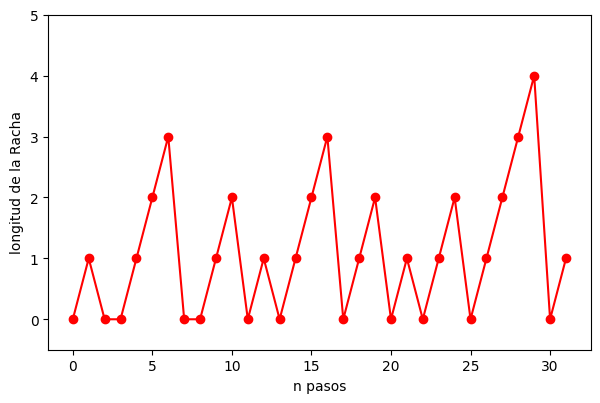

In [17]:
p = 0.7   # Probabilidad de éxito 
q = 1 - p  # Probabilidad de fracaso 

racha_actual = 0
historial_rachas = [0]
historial_letras = [] 
corriendo = False

# Simulación 
def simular_paso():
    global racha_actual, corriendo
    
    if not corriendo:
        return  # Si se presiona parar, no hace nada

    # Ensayo de Bernoulli (Solo para acotar los valores aleatorios en p y q)
    val = random.random()
    if val < p:
        racha_actual += 1
        historial_letras.append('p') # Se guarda p cuando es éxito
    else:
        racha_actual = 0
        historial_letras.append('q') # Se guarda q cuando es fracaso

    # Guardar historial
    historial_rachas.append(racha_actual)
    if len(historial_rachas) > 50:  # Mantener solo los últimos 50 pasos en gráfica, para que no se desborde
        historial_rachas.pop(0)

    # Actualizar la gráfica en la interfaz
    ax.clear()
    ax.plot(historial_rachas, color="red", marker="o", linestyle="-")
    ax.set_ylabel("longitud de la Racha")
    ax.set_xlabel("n pasos") 
    ax.set_ylim(-0.5, max(max(historial_rachas) + 1, 5))
    canvas.draw()

    # Ciclo infinito
    ventana.after(500, simular_paso)

def iniciar():
    global corriendo
    if not corriendo:
        corriendo = True
        boton_iniciar.config(state="disabled")
        boton_parar.config(state="normal")
        simular_paso()

def parar():
    global corriendo
    corriendo = False
    boton_iniciar.config(state="normal")
    boton_parar.config(state="disabled")


# Interfaz gráfica de la simulación
ventana = tk.Tk()
ventana.title("Simulación de Cadena de Rachas")
ventana.geometry("700x500")

# Panel de botones
frame_botones = ttk.Frame(ventana)
frame_botones.pack(pady=15)

boton_iniciar = ttk.Button(frame_botones, text="Iniciar", command=iniciar)
boton_iniciar.pack(side="left", padx=10)

boton_parar = ttk.Button(frame_botones, text="Parar", command=parar, state="disabled")
boton_parar.pack(side="left", padx=10)

# Integración de la gráfica de Matplotlib en Tkinter
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=100)
canvas = FigureCanvasTkAgg(fig, master=ventana)
canvas.get_tk_widget().pack(pady=5, fill="both", expand=True)

# Inicializar gráfico vacío con etiquetas limpias
ax.plot(historial_rachas)
ax.set_ylabel("Longitud de la Racha")
ax.set_xlabel("n pasos")
canvas.draw()

# Ejecutar
ventana.mainloop()
print(historial_letras)

### 2. Matriz de transición

In [18]:
def construir_matriz_transicion(p: float, N: int) -> np.ndarray:
    q = 1 - p
    P = np.zeros((N + 1, N + 1))
    
    for estado_actual in range(N):
        P[estado_actual, estado_actual + 1] = p      # Éxito
        P[estado_actual, 0]                 = q      # Fracaso

    P[N, N] = p      # Éxito
    P[N, 0] = q      # Fracaso
    
    return P

N = 8      # Racha máxima para visualización, ya que es "infinita"
matriz_P = construir_matriz_transicion(p, N)

# Encabezado con los estados destino
print(" " * 15, end="")
for destino in range(N + 1):
    print(f"   {destino:^5}   ", end="")
print("\n" + "-" * (15 + 8 * (N + 1)))

# Cada fila de la matriz
for origen in range(N + 1):
    print(f"      Estado {origen}     |", end="")
    for destino in range(N + 1):
        valor = matriz_P[origen, destino]
        print(f"   {valor:5.2f}  ", end="")
    print()

                    0          1          2          3          4          5          6          7          8     
---------------------------------------------------------------------------------------
      Estado 0     |    0.30      0.70      0.00      0.00      0.00      0.00      0.00      0.00      0.00  
      Estado 1     |    0.30      0.00      0.70      0.00      0.00      0.00      0.00      0.00      0.00  
      Estado 2     |    0.30      0.00      0.00      0.70      0.00      0.00      0.00      0.00      0.00  
      Estado 3     |    0.30      0.00      0.00      0.00      0.70      0.00      0.00      0.00      0.00  
      Estado 4     |    0.30      0.00      0.00      0.00      0.00      0.70      0.00      0.00      0.00  
      Estado 5     |    0.30      0.00      0.00      0.00      0.00      0.00      0.70      0.00      0.00  
      Estado 6     |    0.30      0.00      0.00      0.00      0.00      0.00      0.00      0.70      0.00  
      Estado 7     |

### 3. Clases de comunicación

In [ ]:
letras_simuladas = historial_letras

# Rachas paso a paso
rachas_paso_a_paso = [0]
racha_actual = 0
for letra in letras_simuladas:
    if letra == 'p':
        racha_actual += 1
    else:
        racha_actual = 0
    rachas_paso_a_paso.append(racha_actual)

conexiones_encontradas = set()
for t in range(len(rachas_paso_a_paso) - 1):
    origen = rachas_paso_a_paso[t]
    destino = rachas_paso_a_paso[t+1]
    if origen != destino:
        conexiones_encontradas.add((origen, destino))

print("Estados accesibles de la simulación:")
for origen, destino in sorted(conexiones_encontradas):
    print(f" {origen} a {destino}")

estados_visitados = sorted(list(set(rachas_paso_a_paso)))

print("\nClases de comunicación:")
cadena_igualdad = " = ".join(f"C({estado})" for estado in estados_visitados)
print(f"  {cadena_igualdad}")

Estados accesibles de la simulación:
 0 a 1
 1 a 0
 1 a 2
 2 a 0
 2 a 3
 3 a 0
 3 a 4
 4 a 0

Clases de comunicación:
  C(0) = C(1) = C(2) = C(3) = C(4)
